This notebook is created for benchmarking purposes!

We use QUEKO benchmarks here.  Those are graph edges

In [1]:
INDEX_CONNECTION_LIST = {"Ourense": [(0, 1), (1, 2), (1, 3), (3, 4)],
                       "Sycamore": [(0, 6), (1, 6), (1, 7), (2, 7), (2, 8), (3, 8), (3, 9), (4, 9), (4, 10), (5, 10), (5, 11),
                                    (6, 12), (6, 13), (7, 13), (7, 14), (8, 14), (8, 15), (9, 15), (9, 16), (10, 16), (10, 17), (11, 17),
                                    (12, 18), (13, 18), (13, 19), (14, 19), (14, 20), (15, 20), (15, 21), (16, 21), (16, 22), (17, 22), (17, 23),
                                    (18, 24), (18, 25), (19, 25), (19, 26), (20, 26), (20, 27), (21, 27), (21, 28), (22, 28), (22, 29), (23, 29),
                                    (24, 30), (25, 30), (25, 31), (26, 31), (26, 32), (27, 32), (27, 33), (28, 33), (28, 34), (29, 34), (29, 35),
                                    (30, 36), (30, 37), (31, 37), (31, 38), (32, 38), (32, 39), (33, 39), (33, 40), (34, 40), (34, 41), (35, 41),
                                    (36, 42), (37, 42), (37, 43), (38, 43), (38, 44), (39, 44), (39, 45), (40, 45), (40, 46), (41, 46), (41, 47),
                                    (42, 48), (42, 49), (43, 49), (43, 50), (44, 50), (44, 51), (45, 51), (45, 52), (46, 52), (46, 53), (47, 53)],
                       "Rochester": [(0, 1), (1, 2), (2, 3), (3, 4),
                                     (0, 5), (4, 6), (5, 9), (6, 13),
                                     (7, 8), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15),
                                     (7, 16), (11, 17), (15, 18), (16, 19), (17, 23), (18, 27),
                                     (19, 20), (20, 21), (21, 22), (22, 23), (23, 24), (24, 25), (25, 26), (26, 27),
                                     (21, 28), (25, 29), (28, 32), (29, 36),
                                     (30, 31), (31, 32), (32, 33), (33, 34), (34, 35), (35, 36), (36, 37), (37, 38),
                                     (30, 39), (34, 40), (38, 41), (39, 42), (40, 46), (41, 50),
                                     (42, 43), (43, 44), (44, 45), (45, 46), (46, 47), (47, 48), (48, 49), (49, 50),
                                     (44, 51), (48, 52)],
                       "Tokyo": [(0, 1), (1, 2), (2, 3), (3, 4),
                                 (0, 5), (1, 6), (1, 7), (2, 6), (2, 7), (3, 8), (3, 9), (4, 8), (4, 9),
                                 (5, 6), (6, 7), (7, 8), (8, 9),
                                 (5, 10), (5, 11), (6, 10), (6, 11), (7, 12), (7, 13), (8, 12), (8, 13), (9, 14),
                                 (10, 11), (11, 12), (12, 13), (13, 14),
                                 (10, 15), (11, 16), (11, 17), (12, 16), (12, 17), (13, 18), (13, 19), (14, 18), (14, 19),
                                 (15, 16), (16, 17), (17, 18), (18, 19)],
                       "Aspen-4": [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7),
                                   (0, 8), (3, 11), (4, 12), (7, 15),
                                   (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15)]
                       }


Now let's create the connection graphs from that. Or even custom backend .. 

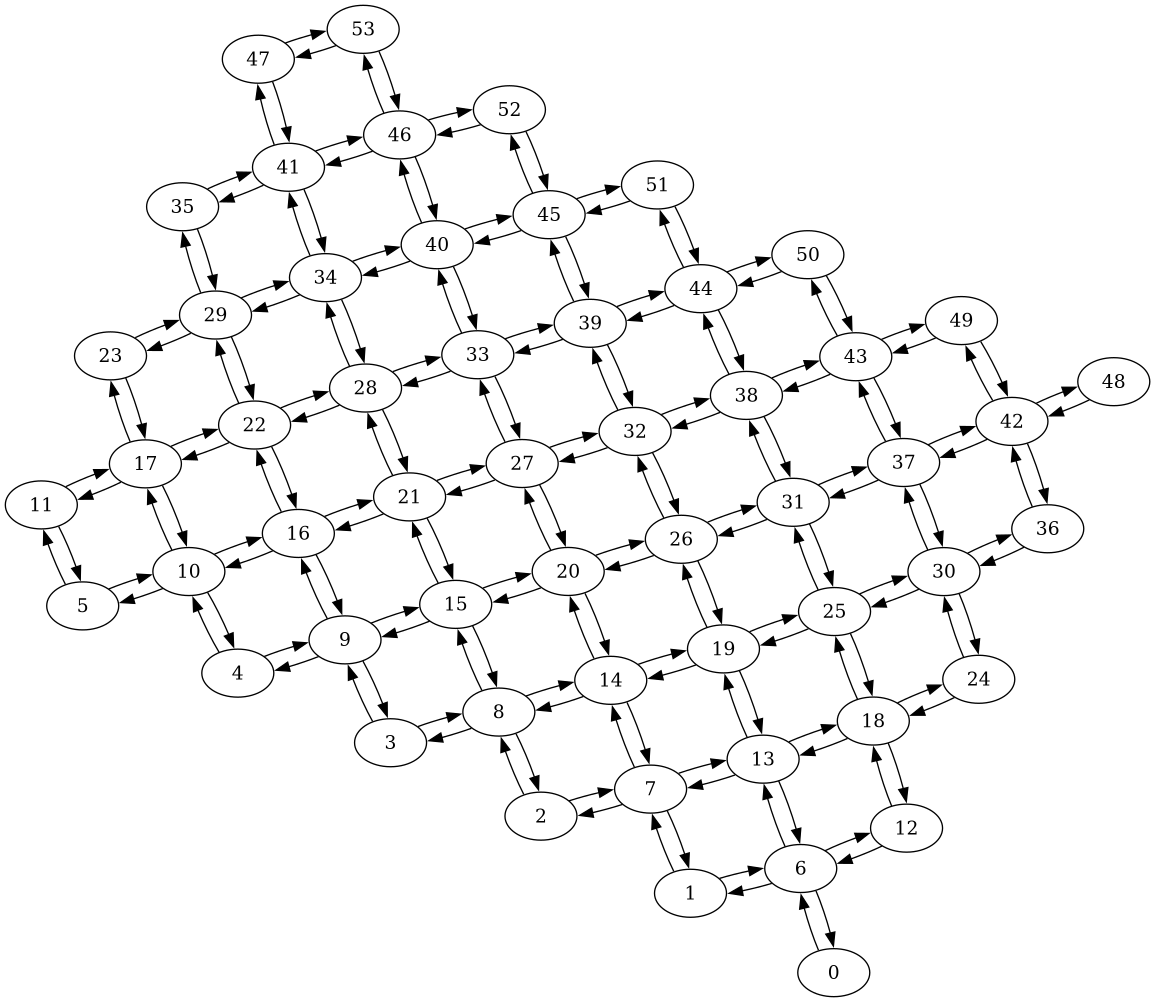

In [2]:
import networkx as nx
import itertools
import quariadne.circuit
import qiskit.transpiler

sycamore_edgelist_undirected = INDEX_CONNECTION_LIST["Sycamore"]
sycamore_graph_undirected = nx.from_edgelist(sycamore_edgelist_undirected)
sycamore_edgelist_directed = sycamore_graph_undirected.to_directed()
sycamore_directed_edgelist = list(sycamore_edgelist_directed.edges())
sycamore_coupling_map = qiskit.transpiler.CouplingMap(sycamore_directed_edgelist)
sycamore_coupling_map.draw()

Now let's fetch circuits!

In [3]:
import qiskit.qasm2
trial_bench = qiskit.qasm2.load("../QUEKO-benchmark/BNTF/54QBT_45CYC_QSE_9.qasm")
trial_bench.draw('mpl')

Okay, now let's check our program. 

In [ ]:
basis_passmanager = qiskit.transpiler.generate_preset_pass_manager(coupling_map=sycamore_coupling_map, optimization_level=0, routing_method="quariadne_lp", layout_method="quariadne_lp")

physical = basis_passmanager.run(trial_bench)
physical.draw("mpl")

entered the router
{<RoutingVariableType.MAPPING: 'mapping'>: {'shape': (25811, 54, 54), 'flat_shape': np.uint64(75264876), 'offset': np.uint64(0)}, <RoutingVariableType.GATE_EXECUTION: 'gate_execution'>: {'shape': (25811, 487, 176), 'flat_shape': np.uint64(2212312432), 'offset': np.uint64(75264876)}, <RoutingVariableType.QUBIT_MOVEMENT: 'qubit_movement'>: {'shape': (25811, 54, 54, 54), 'flat_shape': np.uint64(4064303304), 'offset': np.uint64(2287577308)}}
starting generating the constraints


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator

 
with Session(backend=manila_backend) as session:
    # Submit a request to the Sampler primitive within the session.
    sampler = Sampler(mode=session)
    job = sampler.run([physical])
    pub_result = job.result()[0]
    print(pub_result)
